# Pet Insurance Risk Segmentation Analysis

## Objective

Analyse claim severity drivers across:

- Species
- Breed
- Age
- Coverage Level
- Excess

Identify high-risk customer segments and potential pricing implications.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/pet_insurance_claims.csv"
)

print(df.shape)

(188318, 142)


# Executive Summary

The analysis identifies age, coverage level and breed as the primary business drivers of expected claim severity within the portfolio.

Among the engineered pricing variables, age exhibits the strongest positive relationship with claim severity, followed by coverage level. Comprehensive policies consistently produce the highest expected claim costs, while several breeds—including Dachshunds and French Bulldogs—remain high-risk regardless of policy type.

The interaction analysis further demonstrates that claim severity cannot be explained by individual risk factors alone. High-risk breeds insured under Comprehensive policies represent the greatest financial exposure.

These findings support the adoption of a multi-factor pricing framework and provide evidence for enhanced underwriting, premium differentiation and portfolio risk management.

## Claim Severity by Species

### Objective

Compare the average adjusted claim amount between Dogs and Cats.

### Business Question

Do Dogs generate higher expected claim severity than Cats?

In [2]:
species_summary = (
    df.groupby("species")["adjusted_claim_amount"]
      .mean()
      .sort_values(ascending=False)
)

species_summary

species
Dog    4315.424905
Cat    4033.737869
Name: adjusted_claim_amount, dtype: float64

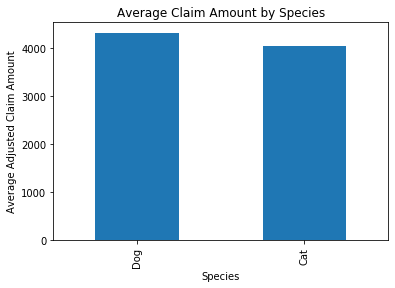

In [3]:
species_summary.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Claim Amount by Species")
plt.xlabel("Species")
plt.ylabel("Average Adjusted Claim Amount")

plt.show()

### Observation

Dogs show a higher average adjusted claim amount than Cats.

This suggests that dogs have greater expected claim severity in this simulated pet insurance portfolio, which is consistent with higher-cost injury and orthopaedic risks commonly associated with dogs.

## Claim Severity by Breed

### Objective

Compare average adjusted claim amount across breeds.

### Business Question

Which breeds generate the highest expected claim severity?

In [4]:
breed_summary = (
    df.groupby("breed")["adjusted_claim_amount"]
      .mean()
      .sort_values(ascending=False)
)

breed_summary

breed
Dachshund             5396.694730
French Bulldog        5122.509056
Persian               4505.893920
German Shepherd       4334.116165
Maine Coon            4182.629702
Golden Retriever      4132.719638
Siamese               3997.565250
Labrador              3943.834875
Ragdoll               3806.500446
Domestic Shorthair    3666.490000
Border Collie         3652.281008
Kelpie                3623.478809
Name: adjusted_claim_amount, dtype: float64

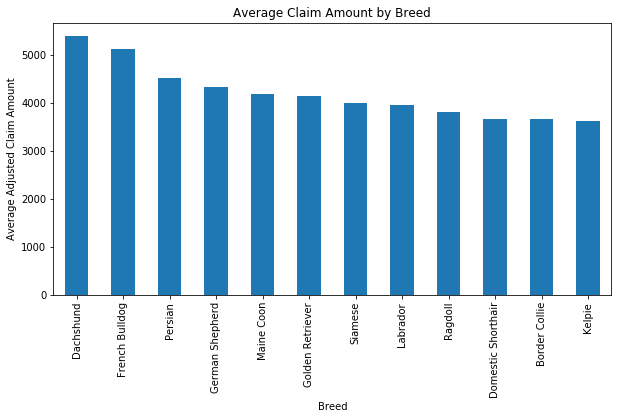

In [5]:
breed_summary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Claim Amount by Breed")
plt.xlabel("Breed")
plt.ylabel("Average Adjusted Claim Amount")

plt.show()

### Observation

Dachshunds and French Bulldogs exhibit the highest average adjusted claim amounts, while Border Collies and Kelpies have the lowest.

The observed ranking is consistent with the simulated breed risk assumptions, where breeds predisposed to hereditary, respiratory, or orthopaedic conditions are associated with greater expected claim severity.

These findings illustrate how breed characteristics can contribute to differences in expected insurance costs.

## Claim Severity by Pet Age

### Objective

Evaluate how claim severity changes across different pet age groups.

### Business Question

How does claim severity vary as pets become older?

In [6]:
age_summary = (
    df.groupby("pet_age")["adjusted_claim_amount"]
      .mean()
)

age_summary

pet_age
0     2899.486829
1     2925.248549
2     2932.114676
3     3689.061521
4     3686.734507
5     3644.816086
6     3695.756045
7     4747.321568
8     4738.759845
9     4718.115040
10    4820.260472
11    6657.326658
12    6576.274358
13    6472.815441
14    6533.808389
15    6525.883135
Name: adjusted_claim_amount, dtype: float64

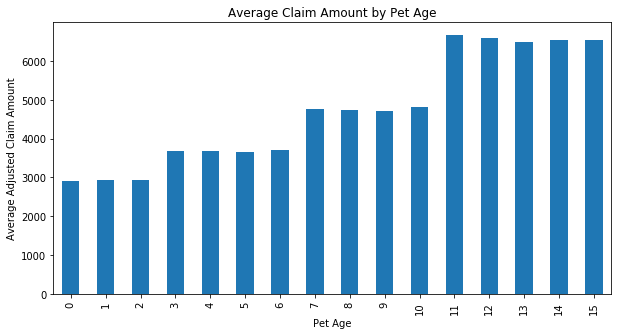

In [7]:
age_summary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Claim Amount by Pet Age")
plt.xlabel("Pet Age")
plt.ylabel("Average Adjusted Claim Amount")

plt.show()

### Observation

Claim severity increases steadily as pets become older.

Young pets (0–2 years) exhibit the lowest average claim amount, while senior pets (11 years and above) generate substantially higher expected claim costs.

This trend reflects the higher prevalence of chronic diseases, degenerative conditions, and age-related veterinary expenses among older pets, making age one of the strongest predictors of claim severity.

## Claim Severity by Coverage Level

### Objective

Evaluate how claim severity differs across policy coverage levels.

### Business Question

Do Comprehensive policies generate higher expected claim severity than Basic and Standard policies?

In [8]:
coverage_summary = (
    df.groupby("coverage_level")["adjusted_claim_amount"]
      .mean()
      .sort_values()
)

coverage_summary

coverage_level
Basic            3286.053410
Standard         4103.037788
Comprehensive    5307.238421
Name: adjusted_claim_amount, dtype: float64

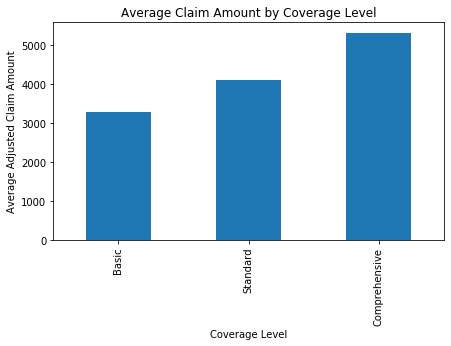

In [24]:
coverage_summary.plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Average Claim Amount by Coverage Level")
plt.xlabel("Coverage Level")
plt.ylabel("Average Adjusted Claim Amount")

plt.savefig("../images/coverage_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

Comprehensive policies generate the highest average adjusted claim amount, followed by Standard and Basic policies.

This reflects the broader reimbursement structure of Comprehensive coverage and suggests that coverage level is an important driver of expected claim severity.

## Claim Severity by Excess

### Objective

Assess how excess level affects expected claim severity.

### Business Question

Do higher excess levels correspond to lower expected insurer claim costs?

In [10]:
excess_summary = (
    df.groupby("excess")["adjusted_claim_amount"]
      .mean()
      .sort_index()
)

excess_summary

excess
0      5232.733905
100    4345.575603
250    3841.139897
500    3221.893289
Name: adjusted_claim_amount, dtype: float64

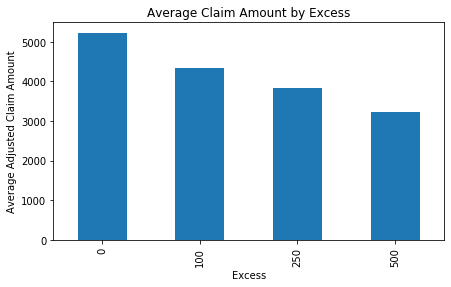

In [11]:
excess_summary.plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Average Claim Amount by Excess")
plt.xlabel("Excess")
plt.ylabel("Average Adjusted Claim Amount")

plt.show()

### Observation

Policies with lower excess levels show higher average adjusted claim amounts, while higher excess levels are associated with lower expected claim severity.

This is consistent with the assumption that higher policyholder cost-sharing reduces insurer claim exposure.

# High-Risk Segment Identification

## Objective

Identify customer segments with the highest expected claim severity by combining multiple risk factors.

## Business Question

Which combinations of breed and coverage level generate the highest expected claim costs?

These insights can help insurers identify high-risk portfolios and support pricing strategy.

In [12]:
segment_summary = (
    df.groupby(
        ["breed", "coverage_level"]
    )["adjusted_claim_amount"]
    .mean()
    .sort_values(ascending=False)
)

segment_summary.head(15)

breed               coverage_level
Dachshund           Comprehensive     6709.814611
French Bulldog      Comprehensive     6374.834536
Persian             Comprehensive     5602.714784
German Shepherd     Comprehensive     5372.720775
Maine Coon          Comprehensive     5228.278658
Golden Retriever    Comprehensive     5169.842383
Dachshund           Standard          5165.194936
Labrador            Comprehensive     4914.381490
French Bulldog      Standard          4897.300437
Siamese             Comprehensive     4872.839549
Ragdoll             Comprehensive     4786.894414
Domestic Shorthair  Comprehensive     4611.210453
Border Collie       Comprehensive     4605.792512
Kelpie              Comprehensive     4486.853526
Persian             Standard          4424.530352
Name: adjusted_claim_amount, dtype: float64

In [13]:
top_segments = (
    segment_summary
    .reset_index()
    .head(10)
)

top_segments

,breed,coverage_level,adjusted_claim_amount
0,Dachshund,Comprehensive,6709.814611
1,French Bulldog,Comprehensive,6374.834536
2,Persian,Comprehensive,5602.714784
3,German Shepherd,Comprehensive,5372.720775
4,Maine Coon,Comprehensive,5228.278658
5,Golden Retriever,Comprehensive,5169.842383
6,Dachshund,Standard,5165.194936
7,Labrador,Comprehensive,4914.381490
8,French Bulldog,Standard,4897.300437
9,Siamese,Comprehensive,4872.839549


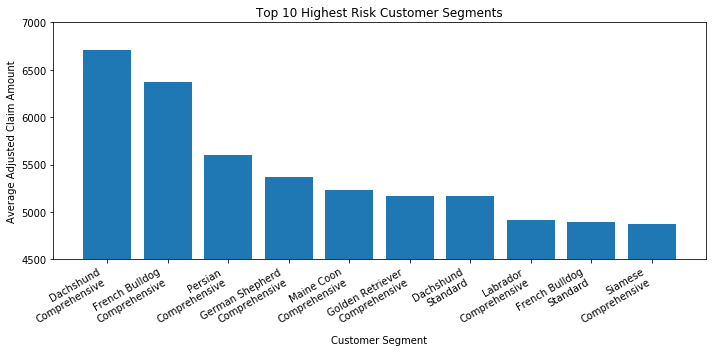

In [14]:
plt.figure(figsize=(10,5))

plt.bar(
    top_segments["breed"] + "\n" + top_segments["coverage_level"],
    top_segments["adjusted_claim_amount"]
)

plt.xticks(rotation=30, ha="right")

plt.title("Top 10 Highest Risk Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Average Adjusted Claim Amount")

plt.ylim(4500, 7000)

plt.tight_layout()
plt.show()

### Observation

The highest expected claim severity is concentrated among comprehensive policies covering breeds with elevated medical risk factors, particularly Dachshunds, French Bulldogs and Persian cats.

Notably, Comprehensive coverage consistently appears among the highest-risk segments, indicating that policy design amplifies the underlying breed-related claim severity.

These findings suggest that insurers may consider differentiated pricing, underwriting rules or targeted portfolio monitoring for these customer segments.

### Business Insight

Rather than considering individual risk factors independently, insurers should evaluate the combined effect of breed and policy design when estimating expected claim costs.

# Breed × Coverage Risk Matrix

## Objective

Visualise the combined effect of breed and coverage level on expected claim severity.

## Business Question

Which breed and coverage combinations generate the highest expected claim amounts?

A risk matrix provides a more complete portfolio view than ranking only the top customer segments.

In [15]:
risk_matrix = (
    df.pivot_table(
        values="adjusted_claim_amount",
        index="breed",
        columns="coverage_level",
        aggfunc="mean"
    )
)

risk_matrix

coverage_level,Basic,Comprehensive,Standard
breed,,,
Border Collie,2821.560373,4605.792512,3488.585834
Dachshund,4204.334085,6709.814611,5165.194936
Domestic Shorthair,2735.721503,4611.210453,3554.321655
French Bulldog,4049.014603,6374.834536,4897.300437
German Shepherd,3338.318975,5372.720775,4181.072976
Golden Retriever,3203.728477,5169.842383,3955.961894
Kelpie,2750.569163,4486.853526,3545.550035
Labrador,3011.688771,4914.381490,3808.676409
Maine Coon,3242.338613,5228.278658,4005.761338


In [21]:
risk_matrix = risk_matrix.sort_values(
    by="Comprehensive",
    ascending=False
)

risk_matrix

coverage_level,Basic,Standard,Comprehensive
breed,,,
Dachshund,4204.334085,5165.194936,6709.814611
French Bulldog,4049.014603,4897.300437,6374.834536
Persian,3440.077155,4424.530352,5602.714784
German Shepherd,3338.318975,4181.072976,5372.720775
Maine Coon,3242.338613,4005.761338,5228.278658
Golden Retriever,3203.728477,3955.961894,5169.842383
Labrador,3011.688771,3808.676409,4914.381490
Siamese,3044.466674,3948.433581,4872.839549
Ragdoll,2938.947761,3630.513488,4786.894414


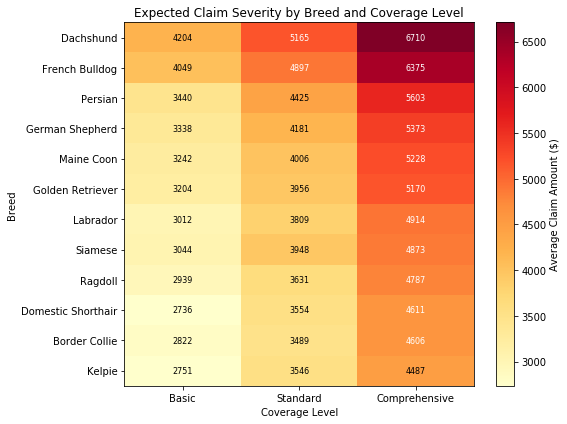

In [23]:
plt.figure(figsize=(8,6))

risk_matrix = risk_matrix[
    ["Basic", "Standard", "Comprehensive"]
]

plt.imshow(
    risk_matrix,
    aspect="auto",
    cmap="YlOrRd"
)

plt.colorbar(label="Average Claim Amount ($)")

plt.xticks(
    range(len(risk_matrix.columns)),
    risk_matrix.columns
)

plt.yticks(
    range(len(risk_matrix.index)),
    risk_matrix.index
)

for i in range(len(risk_matrix.index)):
    for j in range(len(risk_matrix.columns)):
        value = risk_matrix.iloc[i, j]
        text_color = "white" if value > 4500 else "black"

        plt.text(
            j,
            i,
            f"{value:.0f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8
        )

plt.title("Expected Claim Severity by Breed and Coverage Level")

plt.xlabel("Coverage Level")
plt.ylabel("Breed")


plt.tight_layout()

plt.savefig(
    "../images/risk_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Observation

The risk matrix highlights a clear interaction between breed risk and policy coverage.

Across nearly all breeds, Comprehensive policies generate the highest expected claim severity. The effect is strongest for high-risk breeds such as Dachshunds and French Bulldogs.

This suggests that pricing and underwriting should consider combinations of pet characteristics and policy design, rather than assessing each risk factor independently.

# Risk Factor Correlation Analysis

## Objective

Evaluate the relative strength of engineered pricing variables and their association with expected claim severity.

## Business Question

Which engineered pricing variables demonstrate the strongest association with expected claim severity?

In [18]:
risk_features = [
    "breed_risk_factor",
    "age_risk_factor",
    "coverage_risk_factor",
    "excess_risk_factor"
]

feature_corr = (
    df[
        risk_features +
        ["adjusted_claim_amount"]
    ]
    .corr()["adjusted_claim_amount"]
    .drop("adjusted_claim_amount")
    .sort_values(ascending=False)
)

feature_corr

age_risk_factor         0.254668
coverage_risk_factor    0.160030
breed_risk_factor       0.126683
excess_risk_factor      0.124940
Name: adjusted_claim_amount, dtype: float64

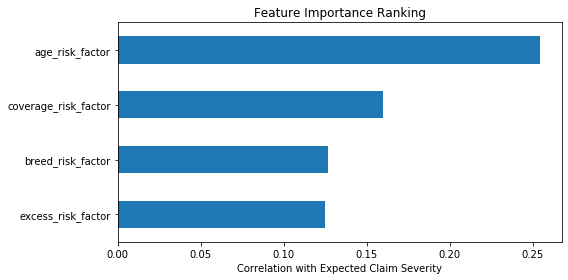

In [19]:
feature_corr.sort_values().plot(
    kind="barh",
    figsize=(8,4)
)

plt.title("Feature Importance Ranking")
plt.xlabel("Correlation with Expected Claim Severity")
plt.ylabel("")

plt.tight_layout()
plt.show()

## Observation

Age risk factor shows the strongest positive relationship with expected claim severity among the engineered pricing variables.

Coverage level also demonstrates a meaningful positive association with claim severity, indicating that broader reimbursement structures contribute to higher insurer costs.

Breed risk factor exhibits a moderate positive relationship, reflecting genetic differences in expected veterinary expenses.

Although excess risk factor remains positively correlated with claim severity in this engineered dataset, its influence is comparatively weaker than the other pricing variables.

Overall, age and coverage appear to be the primary business drivers of expected claim severity in this portfolio.

## Business Implications

The analysis suggests that expected claim severity is driven by multiple interacting pricing factors rather than a single characteristic.

For pricing strategy, insurers may consider:

• Applying stronger age-based premium adjustments for older pets.

• Maintaining differentiated pricing across coverage tiers, particularly for Comprehensive policies.

• Introducing additional underwriting review for high-risk breed and coverage combinations.

• Monitoring customer behaviour across excess selections to optimise policy profitability while maintaining affordability.

Overall, these findings support a multi-factor pricing framework rather than relying on individual customer attributes in isolation.